# Workshop on signal analysis and feature extraction

Course: Intelligent Sensing and Sense Making

Website: https://www.iss.nus.edu.sg/executive-education/course/detail/intelligent-sensing-and-sense--making/artificial-intelligence

Contact: Tian Jing

Email: tianjing@nus.edu.sg

**Objective**: In this workshop, we will extract statistical features from wavelet coefficients from human wearable sensor data, and then perform classification for human activity classification

**Reference**: PyWavelets - Wavelet Transforms in Python, https://github.com/PyWavelets/pywt. The Help document of this tool is provided at https://pywavelets.readthedocs.io/en/latest/


**Dataset**: UCI Human Activity Recognition Using Smartphones. This dataset contains sensor data for 30 persons, each person performed six activities (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING) wearing a smartphone (Samsung Galaxy S II) on the waist. Using its embedded accelerometer and gyroscope, 3-axial linear acceleration and 3-axial angular velocity are recorded at a constant rate of 50Hz. Website: https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones

In [1]:
!pip install PyWavelets

In [1]:
# Load necessary packages
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pywt
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix


In [3]:
# Grant access to google drive.
# Run this cell, then you’ll see a link, click on that link, allow access
# Copy the code that pops up, paste it in the box, hit Enter

from google.colab import drive
drive.mount('/content/gdrive')

# Change working directory to be current folder
# os.chdir('/content/gdrive/My Drive/Your Folder Name/Your sub Folder Name')
os.chdir('/content/gdrive/My Drive/ISSM/Day2')
!ls


Mounted at /content/gdrive
data  ISSM_Day2_wk_signal_yourname.ipynb


### Goal
Goal: Classify human activities (UCI HAR dataset) using wavelet features extracted from 9 inertial sensor signals per sample, then train a Gaussian Naive Bayes classifier and report a confusion matrix.

#### Data loading and shapes

In [4]:
# Load training data and label, test data and label

def read_signals(filename): #reads a text file into a list of lists of floats (each line = a window of 128 samples).
    with open(filename, 'r') as fp:
        data = fp.read().splitlines()
        data = map(lambda x: x.rstrip().lstrip().split(), data)
        data = [list(map(float, line)) for line in data]
    return data

def read_labels(filename): #reads integer activity labels (UCI HAR uses 1–6)
    with open(filename, 'r') as fp:
        activities = fp.read().splitlines()
        activities = list(map(int, activities))
    return activities

#use this to shuffle and creat random purmutation over samples N -- for robustness
#keep dataset (first axis) and labels aligned
def randomize(dataset, labels):
    permutation = np.random.permutation(labels.shape[0])
    shuffled_dataset = dataset[permutation, :, :]
    shuffled_labels = labels[permutation]
    return shuffled_dataset, shuffled_labels

INPUT_FOLDER_TRAIN = 'Day2/data/UCI_HAR/train/Inertial Signals/'
INPUT_FOLDER_TEST = 'Day2/data/UCI_HAR/test/Inertial Signals/'

#load 9 training and 9 test signals (body_acc/gyro/total_acc for x,y,z)
INPUT_FILES_TRAIN = ['body_acc_x_train.txt', 'body_acc_y_train.txt', 'body_acc_z_train.txt',
                     'body_gyro_x_train.txt', 'body_gyro_y_train.txt', 'body_gyro_z_train.txt',
                     'total_acc_x_train.txt', 'total_acc_y_train.txt', 'total_acc_z_train.txt']

INPUT_FILES_TEST = ['body_acc_x_test.txt', 'body_acc_y_test.txt', 'body_acc_z_test.txt',
                     'body_gyro_x_test.txt', 'body_gyro_y_test.txt', 'body_gyro_z_test.txt',
                     'total_acc_x_test.txt', 'total_acc_y_test.txt', 'total_acc_z_test.txt']

LABELFILE_TRAIN = 'Day2/data/UCI_HAR/train/y_train.txt'
LABELFILE_TEST = 'Day2/data/UCI_HAR/test/y_test.txt'

train_signals, test_signals = [], []

#stack and transpose into arrays of shape (N, T, C) = (samples, time_length, components)
# N: number of records (e.g., 7352 train, 2947 test)
# T: length (#points per window), typically 128
# C: 9 components (the 9 sensor channels)
for input_file in INPUT_FILES_TRAIN:
    signal = read_signals(INPUT_FOLDER_TRAIN + input_file)
    train_signals.append(signal)
train_signals = np.transpose(np.array(train_signals), (1, 2, 0))

for input_file in INPUT_FILES_TEST:
    signal = read_signals(INPUT_FOLDER_TEST + input_file)
    test_signals.append(signal)
test_signals = np.transpose(np.array(test_signals), (1, 2, 0))

train_labels = read_labels(LABELFILE_TRAIN)
test_labels = read_labels(LABELFILE_TEST)

print("The train dataset contains %d records with %d length (# of data points) and %d components (# of sensors)." % (train_signals.shape[0], train_signals.shape[1], train_signals.shape[2]))
print("The test dataset contains %s records with %d length (# of data points) and %d components (# of sensors)." % (test_signals.shape[0], test_signals.shape[1], test_signals.shape[2]))

uci_har_signals_train, uci_har_labels_train = randomize(train_signals, np.array(train_labels))
uci_har_signals_test, uci_har_labels_test = randomize(test_signals, np.array(test_labels))

activity_label = ['WALKING', 'UPSTAIRS', 'DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


The train dataset contains 7352 records with 128 length (# of data points) and 9 components (# of sensors).
The test dataset contains 2947 records with 128 length (# of data points) and 9 components (# of sensors).


#### Feature engineering - wavelets

In [5]:
# Define the feature extraction method for each subband

#return measures for array
def calculate_statistics(list_values):
    median = np.nanpercentile(list_values, 50)
    mean = np.nanmean(list_values)
    std = np.nanstd(list_values)
    var = np.nanvar(list_values)
    return [median, mean, std, var]


# Define feature extraction methods
def get_features(list_values): #call the above function, can be expanded
    statistics = calculate_statistics(list_values)
    return statistics

def get_uci_har_features(dataset, labels, waveletname, waveletlevel):
    uci_har_features = []
    for signal_no in range(0, dataset.shape[0]):

        if ((signal_no % 500) == 0):
            print('get_uci_har_features, loop %d/%d' % (signal_no, len(dataset)))
        features = []

        for signal_comp in range(0, dataset.shape[2]): # 9 components
            signal = dataset[signal_no, :, signal_comp]
            #discrete wavelet decomposition;
            # level=X ==> X+1 subbands
            list_coeff = pywt.wavedec(signal, waveletname, level=waveletlevel)

            # Each subband, compute 4 stats above and append to feature list
            for coeff in list_coeff:
                features += get_features(coeff) # append two lists

        uci_har_features.append(features)
    #stack all features in X
    X = np.array(uci_har_features)
    Y = np.array(labels)
    return X, Y

# Feature count formula:
# n_features = n_components * (waveletlevel + 1) * n_stats
# Here: 9 * (<choice> + 1) * 4 = 144 features per sample if level=3.


In [6]:
# Extract features for both train and test signals
waveletname = 'db4' #(Daubechies-4)
waveletlevel = 3 #a common choice for smooth, compactly supported wavelets suited for inertial signals. Multi-level decomposition captures trends (approximation) + fine variations (details)

print('Generate features for training data')
X_train, Y_train = get_uci_har_features(uci_har_signals_train, uci_har_labels_train, waveletname, waveletlevel)

print('Generate features for test data')
X_test, Y_test = get_uci_har_features(uci_har_signals_test, uci_har_labels_test, waveletname, waveletlevel)

print('X_train shape:', X_train.shape, 'Y_train shape:', Y_train.shape)
print('X_test shape:', X_test.shape, 'Y_test shape:', Y_test.shape)

Generate features for training data
get_uci_har_features, loop 0/7352
get_uci_har_features, loop 500/7352
get_uci_har_features, loop 1000/7352
get_uci_har_features, loop 1500/7352
get_uci_har_features, loop 2000/7352
get_uci_har_features, loop 2500/7352
get_uci_har_features, loop 3000/7352
get_uci_har_features, loop 3500/7352
get_uci_har_features, loop 4000/7352
get_uci_har_features, loop 4500/7352
get_uci_har_features, loop 5000/7352
get_uci_har_features, loop 5500/7352
get_uci_har_features, loop 6000/7352
get_uci_har_features, loop 6500/7352
get_uci_har_features, loop 7000/7352
Generate features for training data
get_uci_har_features, loop 0/2947
get_uci_har_features, loop 500/2947
get_uci_har_features, loop 1000/2947
get_uci_har_features, loop 1500/2947
get_uci_har_features, loop 2000/2947
get_uci_har_features, loop 2500/2947
X_train shape: (7352, 144) Y_train shape: (7352,)
X_test shape: (2947, 144) Y_test shape: (2947,)


In [7]:
# Perform classification, fit gaussian naive bayes
clf = GaussianNB()
clf.fit(X_train, Y_train)

Y_predict = clf.predict(X_test)
print(pd.DataFrame(confusion_matrix(Y_test, Y_predict), index=activity_label, columns=activity_label))



            WALKING  UPSTAIRS  DOWNSTAIRS  SITTING  STANDING  LAYING
WALKING         257       163          76        0         0       0
UPSTAIRS         14       437          20        0         0       0
DOWNSTAIRS       83        99         238        0         0       0
SITTING           0         5           0      422        51      13
STANDING          0        20           0      309       189      14
LAYING            0         7           0       40         0     490


$\color{red}{\text{Discussions}}$

Q1: Recommend and describe a method to integrate both time-domain features and wavelet-domain features together to feed them into the classifier model.

Q2: Design an experiment to evaluate the hyperparameters, including (1) the choice of wavelet filters and (2) the wavelet decomposition levels, of the wavelet-based feature extraction for human activity classification.

In [8]:
# Provide your answers to Q1
#
#
# Provide your answers to Q2
#
#


### Answer 1
Idea: Extract time-domain statistics and wavelet-domain statistics per sensor channel, then concatenate them into one feature vector and feed to a classifier (via a Pipeline so scaling and CV are leakage-safe).
Calculate:
- time domain per channel - mean, median, stfd var, RMS
- wavelet domain per subband at each level - mean, median, std, var

In [8]:
import numpy as np, pywt
from scipy.stats import skew, kurtosis
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

class TimeFeatExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, compute_cross_axis=True):
        self.compute_cross_axis = compute_cross_axis

    def fit(self, X, y=None): return self

    def _zcr(self, x):  # zero-crossing rate
        return np.mean(np.abs(np.diff(np.signbit(x))))

    def transform(self, X):  # X: (N, T, C)
        N, T, C = X.shape
        feats = []
        for n in range(N):
            f = []
            for c in range(C):
                x = X[n, :, c]
                f.extend([
                    np.nanmedian(x), np.nanmean(x), np.nanstd(x), np.nanvar(x),
                    np.sqrt(np.nanmean(x**2)),                   # RMS
                    np.nanmedian(np.abs(x - np.nanmedian(x))),   # MAD
                    np.nanpercentile(x, 75) - np.nanpercentile(x, 25),  # IQR
                    skew(x, nan_policy='omit'), kurtosis(x, nan_policy='omit'),
                    self._zcr(x), np.nansum(x**2), np.nansum(np.abs(x))  # energy, SMA
                ])
            if self.compute_cross_axis:
                # Example: add correlations for the body_acc triad (first 3 chans) etc.
                def triad_corr(triad_idx):
                    x, y, z = [X[n, :, i] for i in triad_idx]
                    cc = lambda a,b: np.corrcoef(a, b)[0,1]
                    return [cc(x,y), cc(y,z), cc(x,z)]
                # Adjust indices to your channel ordering (here 0..8 grouped by x,y,z)
                f.extend(triad_corr([0,1,2]))
                f.extend(triad_corr([3,4,5]))
                f.extend(triad_corr([6,7,8]))
            feats.append(f)
        return np.asarray(feats)

class WaveletFeatExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, wavelet='db4', level=3):
        self.wavelet = wavelet
        self.level = level

    def fit(self, X, y=None): return self

    def _band_stats(self, coeffs):
        e = np.sum(coeffs**2)
        p = (coeffs**2) / (e + 1e-12)
        ent = -np.sum(p * np.log(p + 1e-12))
        return [np.nanmedian(coeffs), np.nanmean(coeffs), np.nanstd(coeffs), np.nanvar(coeffs), e, ent]

    def transform(self, X):  # X: (N, T, C)
        N, T, C = X.shape
        feats = []
        for n in range(N):
            f = []
            for c in range(C):
                coeffs = pywt.wavedec(X[n, :, c], self.wavelet, level=self.level)
                for band in coeffs:              # A_L, D_L, D_{L-1}, ..., D1
                    f.extend(self._band_stats(np.asarray(band)))
            feats.append(f)
        return np.asarray(feats)

# Combine both sets and classify
features = FeatureUnion([
    ('time', TimeFeatExtractor(compute_cross_axis=True)),
    ('wlt',  WaveletFeatExtractor(wavelet='db4', level=3)),
])

pipe = Pipeline([
    ('feat', features),
    ('scaler', StandardScaler(with_mean=False)),  # with_mean=False is safer if sparse; set True if dense
    ('clf', LogisticRegression(max_iter=2000, n_jobs=-1))
])
# pipe.fit(uci_har_signals_train, uci_har_labels_train); preds = pipe.predict(uci_har_signals_test)

In [10]:
pipe.fit(uci_har_signals_train, uci_har_labels_train);
preds = pipe.predict(uci_har_signals_test)

##### Confusion matrix (counts + normalized)

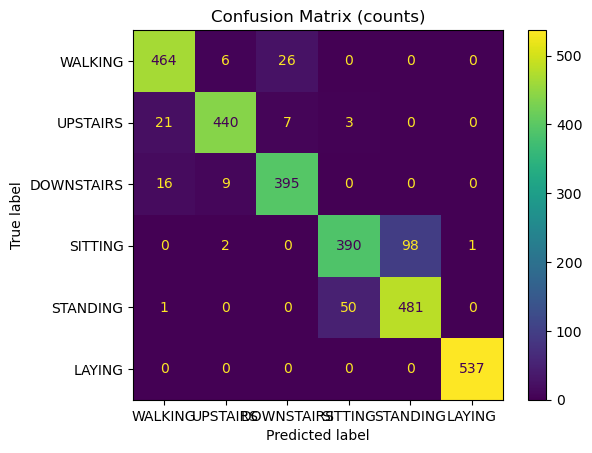

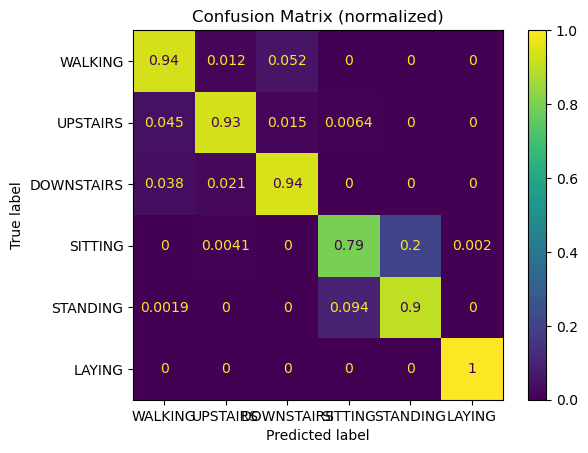

              precision    recall  f1-score   support

     WALKING       0.92      0.94      0.93       496
    UPSTAIRS       0.96      0.93      0.95       471
  DOWNSTAIRS       0.92      0.94      0.93       420
     SITTING       0.88      0.79      0.84       491
    STANDING       0.83      0.90      0.87       532
      LAYING       1.00      1.00      1.00       537

    accuracy                           0.92      2947
   macro avg       0.92      0.92      0.92      2947
weighted avg       0.92      0.92      0.92      2947



In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

activity_label = ['WALKING','UPSTAIRS','DOWNSTAIRS','SITTING','STANDING','LAYING']
y_true = uci_har_labels_test
y_pred = preds

# Counts
cm = confusion_matrix(y_true, y_pred, labels=[1,2,3,4,5,6])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=activity_label)
disp.plot(values_format='d'); plt.title('Confusion Matrix (counts)'); plt.show()

# Normalized by true class
cm_norm = confusion_matrix(y_true, y_pred, labels=[1,2,3,4,5,6], normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=activity_label)
disp.plot(); plt.title('Confusion Matrix (normalized)'); plt.show()

print(classification_report(y_true, y_pred, target_names=activity_label, labels=[1,2,3,4,5,6]))

##### Per-class Precision–Recall curves + macro/micro averages

Average Precision (macro): 0.974 | (micro): 0.980


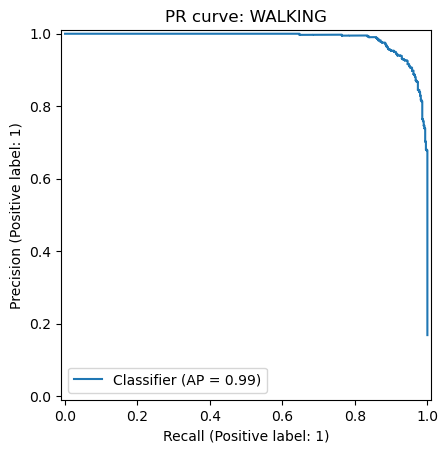

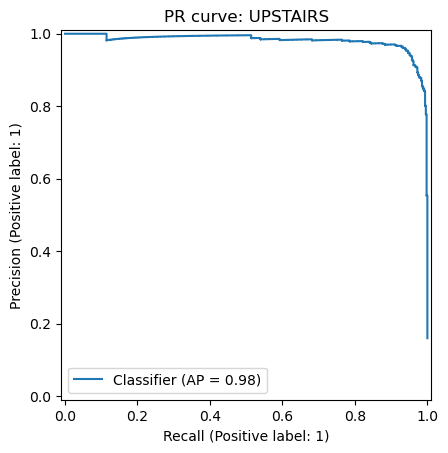

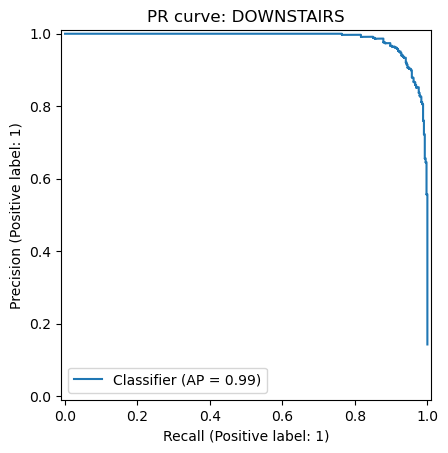

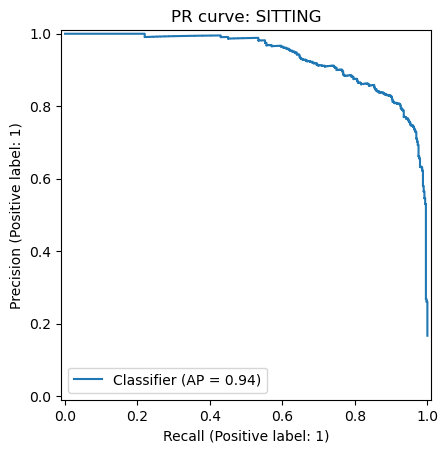

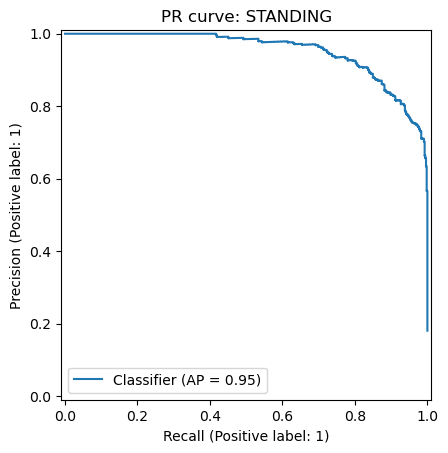

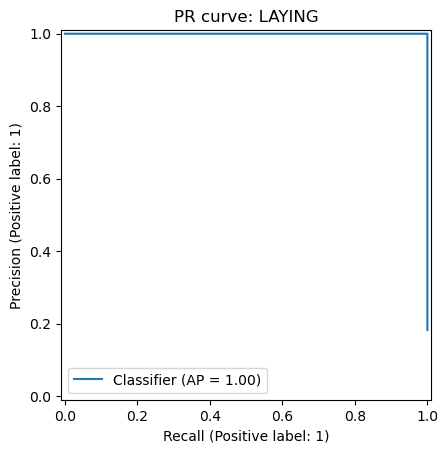

In [16]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
import numpy as np

if hasattr(pipe, "predict_proba"):
    y_score = pipe.predict_proba(uci_har_signals_test)  # (n_samples, n_classes)
    y_bin = label_binarize(y_true, classes=[1,2,3,4,5,6])
    n_classes = y_bin.shape[1]

    ap_macro = average_precision_score(y_bin, y_score, average='macro')
    ap_micro = average_precision_score(y_bin, y_score, average='micro')
    print(f"Average Precision (macro): {ap_macro:.3f} | (micro): {ap_micro:.3f}")

    for i in range(n_classes):
        PrecisionRecallDisplay.from_predictions(y_bin[:, i], y_score[:, i])
        plt.title(f'PR curve: {activity_label[i]}')
        plt.show()

##### ROC curves

In [ ]:
from sklearn.metrics import RocCurveDisplay

if hasattr(pipe, "predict_proba"):
    for i in range(6):
        RocCurveDisplay.from_predictions(y_bin[:, i], y_score[:, i])
        plt.title(f'ROC: {activity_label[i]}')
        plt.show()

##### Top confusions table

In [ ]:
import pandas as pd
pairs = []
for i in range(6):
    for j in range(6):
        if i!=j:
            pairs.append((activity_label[i], activity_label[j], cm[i,j]))
df_conf = pd.DataFrame(pairs, columns=['True','Pred','Count']).sort_values('Count', ascending=False)
print(df_conf.head(10))

#### Wavelet filter choice and decomposition level
Goal:
- Quantify how wavelet family and decomposition level impact downstream classification on UCI HAR.
 - Avoid subject leakage; report statistically reliable results.

Factors (grid)

- Wavelet families (discrete, orthogonal/biorthogonal):
['db2','db3','db4','db6','sym3','sym5','coif1','coif3','bior3.5','dmey']

- Decomposition levels: L ∈ {1,2,3,4,5} subject to feasibility:
ensure L ≤ pywt.dwt_max_level(T, pywt.Wavelet(w).dec_len) for your window length T=128.

##### Use SubjectID so no subject appears in train and validation - prevent leakage

In [17]:
import numpy as np

def read_subjects(filename):
    with open(filename, 'r') as fp:
        return np.array(list(map(int, fp.read().splitlines())))

SUBJECTFILE_TRAIN = 'Day2/data/UCI_HAR/train/subject_train.txt'
SUBJECTFILE_TEST  = 'Day2/data/UCI_HAR/test/subject_test.txt'

subjects_train_raw = read_subjects(SUBJECTFILE_TRAIN)
subjects_test_raw  = read_subjects(SUBJECTFILE_TEST)

# we used randomize() on train/test, modify it to also return subjects:
def randomize_with_groups(dataset, labels, groups):
    permutation = np.random.permutation(labels.shape[0])
    return dataset[permutation], labels[permutation], groups[permutation]

uci_har_signals_train, uci_har_labels_train, uci_har_subjects_train = \
    randomize_with_groups(train_signals, np.array(train_labels), subjects_train_raw)

uci_har_signals_test, uci_har_labels_test, uci_har_subjects_test = \
    randomize_with_groups(test_signals, np.array(test_labels), subjects_test_raw)

In [11]:
from sklearn.model_selection import GridSearchCV, GroupKFold

#use grid to tune hyperparameters

param_grid = {
    'feat__wlt__wavelet': ['db2','db3','db4','db6','sym3','sym5','coif1','coif3','bior3.5','dmey'],
    'feat__wlt__level':   [1,2,3,4,5],
    'clf__C':             [0.1, 1, 10]
}

cv = GroupKFold(n_splits=5)  # because we have subject IDs; else StratifiedKFold(5)
grid = GridSearchCV(pipe, param_grid=param_grid, scoring='f1_macro', cv=cv, n_jobs=-1, verbose=1)


In [ ]:
grid.fit(uci_har_signals_train, uci_har_labels_train, groups=uci_har_subjects_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


**After you finish the workshop, rename and submit your .ipynb file.**